# Notebook 05 — Customer Segmentation (KMeans Clustering)

**Project**: E-Commerce Intelligence Platform  
**Environment**: Google Colab Free  
**Goal**: Segment 206K Instacart users into distinct personas using KMeans clustering, enabling targeted marketing and personalization.

## Why Clustering?
Unlike Notebook 04 (supervised classification), this is **unsupervised learning** — we have no labels. We discover natural groupings in user behavior.

## Use Cases
- **Marketing**: Different campaigns per persona (e.g., re-engagement for lapsed users)
- **Personalization**: Tailor UI/recommendations per segment
- **Business strategy**: Understand customer base composition

## Approach
1. Select behavioral features (orders, reorder ratio, basket size, etc.)
2. Scale features (KMeans uses Euclidean distance)
3. Find optimal K (elbow method + silhouette score)
4. Train KMeans, profile each cluster
5. Name personas based on characteristics
6. Save model for Streamlit segmentation page

## Tool: Scikit-learn KMeans
206K users fits easily in Pandas — no Spark needed (lesson from Notebook 03).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 50)

DATA_PATH = '/content/drive/MyDrive/Colab/instacart-project/data'
PROCESSED_PATH = f'{DATA_PATH}/processed'
MODELS_PATH = f'{DATA_PATH}/models'
RANDOM_STATE = 42

print('Setup complete')

Mounted at /content/drive
Setup complete


## 1. Load User Features

Load the `user_features.parquet` created in Notebook 02 (PySpark). Each row = 1 user, with 12 behavioral features aggregated from 32M order-product transactions.

Expected: **206,209 users × 13 columns** (12 features + `user_id`).

In [2]:
# Load user features from Notebook 02
user_features = pd.read_parquet(f'{PROCESSED_PATH}/user_features.parquet')
print(f'User features: {user_features.shape}')
print(f'Columns: {list(user_features.columns)}')
user_features.head()

User features: (206209, 13)
Columns: ['user_id', 'total_orders', 'total_items_bought', 'avg_basket_size', 'reorder_ratio', 'total_reordered_items', 'avg_order_hour', 'avg_days_between_orders', 'avg_days_between_items', 'weekend_ratio', 'peak_hour_ratio', 'unique_products', 'unique_departments']


,user_id,total_orders,total_items_bought,avg_basket_size,reorder_ratio,total_reordered_items,avg_order_hour,avg_days_between_orders,avg_days_between_items,weekend_ratio,peak_hour_ratio,unique_products,unique_departments
0,1,10,59,5.900000,0.694915,41,10.542373,19.555556,20.259259,0.288136,0.322034,18,7
1,3,12,88,7.333333,0.625000,55,16.352273,12.090909,11.487179,0.704545,0.284091,33,9
2,5,4,37,9.250000,0.378378,14,15.729730,13.333333,14.500000,0.567568,0.297297,23,9
3,6,3,14,4.666667,0.142857,2,17.000000,9.000000,7.800000,0.000000,0.000000,12,5
4,12,5,74,14.800000,0.175676,13,8.959459,25.000000,26.169014,0.337838,0.040541,61,14


In [3]:
# Review feature distributions before clustering
user_features.describe()

,user_id,total_orders,total_items_bought,avg_basket_size,reorder_ratio,total_reordered_items,avg_order_hour,avg_days_between_orders,avg_days_between_items,weekend_ratio,peak_hour_ratio,unique_products,unique_departments
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,15.590367,157.289396,9.951586,0.432249,92.753158,13.546251,15.209435,15.469670,0.359101,0.499169,64.536238,10.827796
std,59527.555167,16.654774,204.208233,5.863570,0.212144,158.400413,2.218474,7.105277,7.207436,0.234062,0.248200,56.592339,3.791768
min,1.000000,3.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,51553.000000,5.000000,39.000000,5.740741,0.267857,10.000000,12.099099,9.416667,9.553797,0.196203,0.327273,25.000000,8.000000
50%,103105.000000,9.000000,83.000000,8.933333,0.428571,33.000000,13.521739,14.500000,14.692308,0.333333,0.500000,48.000000,11.000000
75%,154657.000000,19.000000,188.000000,13.000000,0.595745,101.000000,14.971429,20.285714,20.724409,0.500000,0.671233,86.000000,14.000000
max,206209.000000,99.000000,3725.000000,70.250000,0.989529,3275.000000,23.000000,30.000000,30.000000,1.000000,1.000000,726.000000,21.000000


## 2. Feature Selection for Clustering

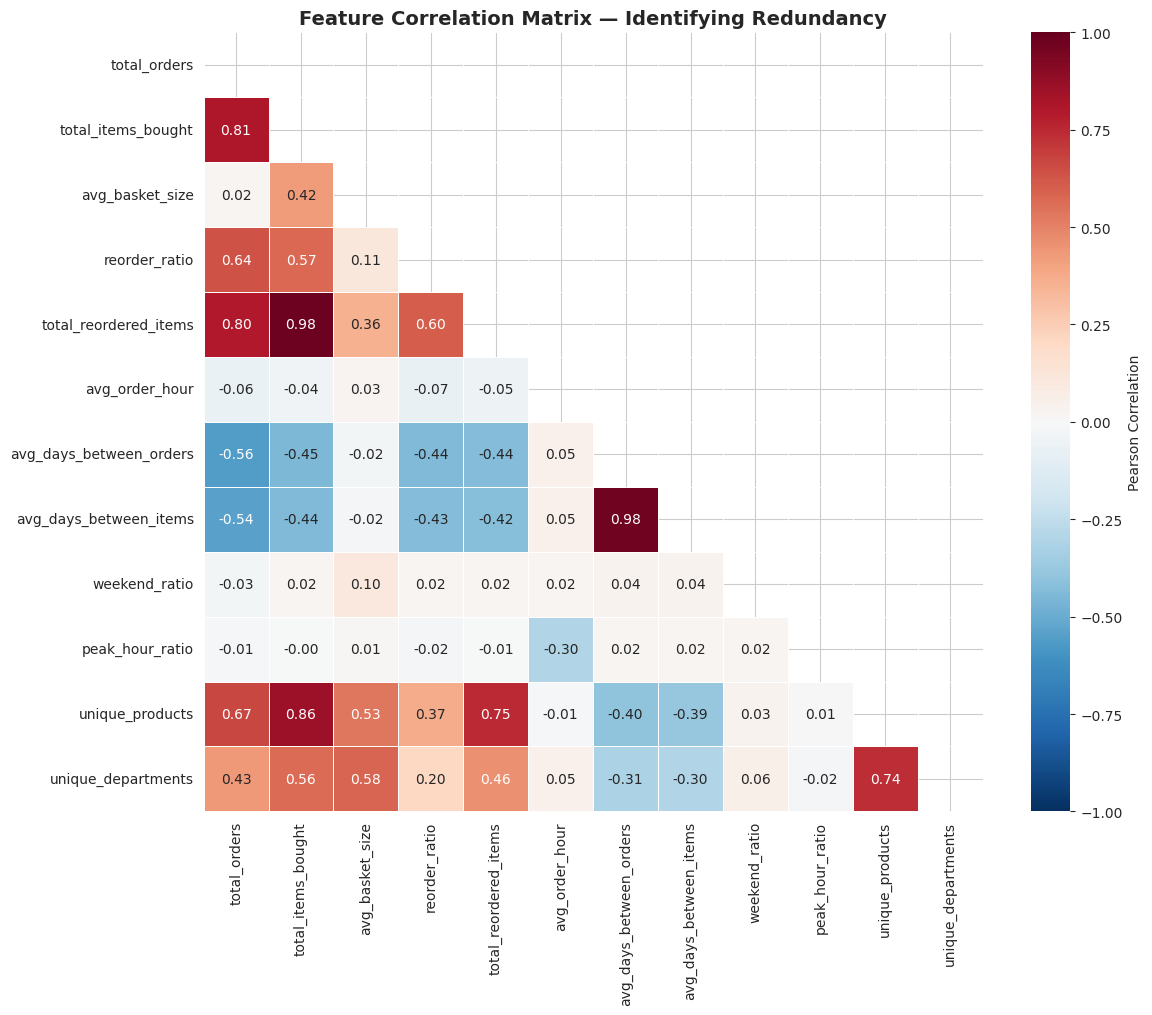

In [4]:
# Correlation heatmap — check for redundancy among ALL 12 features
numeric_cols = user_features.select_dtypes(include=[np.number]).columns.drop('user_id')

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = user_features[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation'},
    ax=ax
)
ax.set_title('Feature Correlation Matrix — Identifying Redundancy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observation — Correlation Analysis

**High correlations (|r| > 0.7) — features we EXCLUDE from clustering:**
- `total_items_bought` ↔ `total_reordered_items` (0.98): Nearly identical — exclude both, keep `total_orders` + `reorder_ratio` instead
- `unique_products` ↔ `total_items_bought` (0.86): More items → more variety — keep `unique_departments` for breadth instead
- `total_orders` ↔ `total_items_bought` (0.81): Both measure volume — keep `total_orders` (simpler, more interpretable)
- `total_orders` ↔ `total_reordered_items` (0.80): Reorder count scales with order count — use `reorder_ratio` instead
- `unique_products` ↔ `total_reordered_items` (0.75): Both scale with volume — already excluded
- `unique_products` ↔ `unique_departments` (0.74): Keep `unique_departments` (broader, more interpretable for personas)
- `avg_days_between_orders` ↔ `avg_days_between_items` (0.98): Essentially the same — keep `avg_days_between_orders` (unbiased, computed from orders not items)

**Among our 6 chosen features**, the highest correlation is `total_orders` ↔ `reorder_ratio` (0.64) — moderate but acceptable since they capture genuinely different behaviors (frequency vs. habit strength). All other pairs are below 0.6.

**Near-zero correlations** confirm `weekend_ratio` (all |r| < 0.10) and `avg_order_hour` are nearly independent dimensions.

In [5]:
# Select the 6 clustering features
CLUSTER_FEATURES = [
    'total_orders',             # Purchase frequency
    'avg_basket_size',          # Shopping volume per trip
    'reorder_ratio',            # Loyalty / habit strength
    'avg_days_between_orders',  # Purchase cadence
    'weekend_ratio',            # Time preference
    'unique_departments',       # Shopping breadth
]

X_raw = user_features[CLUSTER_FEATURES].copy()
print(f'Clustering dataset: {X_raw.shape}')
print(f'\nNull counts:')
print(X_raw.isnull().sum())
print(f'\nFeature ranges (before scaling):')
X_raw.describe().round(2)

Clustering dataset: (206209, 6)

Null counts:
total_orders               0
avg_basket_size            0
reorder_ratio              0
avg_days_between_orders    0
weekend_ratio              0
unique_departments         0
dtype: int64

Feature ranges (before scaling):


,total_orders,avg_basket_size,reorder_ratio,avg_days_between_orders,weekend_ratio,unique_departments
count,206209.00,206209.00,206209.00,206209.00,206209.00,206209.00
mean,15.59,9.95,0.43,15.21,0.36,10.83
std,16.65,5.86,0.21,7.11,0.23,3.79
min,3.00,1.00,0.00,0.00,0.00,1.00
25%,5.00,5.74,0.27,9.42,0.20,8.00
50%,9.00,8.93,0.43,14.50,0.33,11.00
75%,19.00,13.00,0.60,20.29,0.50,14.00
max,99.00,70.25,0.99,30.00,1.00,21.00


### Observation — Feature Ranges

Notice the massive scale differences:
- `total_orders`: 3 to 99 (integers)
- `reorder_ratio`: 0.0 to ~0.99 (fraction)
- `avg_days_between_orders`: 0 to 30 (days)
- `unique_departments`: 1 to 21 (count)

Without scaling, `total_orders` would dominate distance calculations simply because its range is larger. **StandardScaler is essential**.

## 3. Feature Scaling

**StandardScaler**: Transforms each feature to mean=0, std=1. This ensures KMeans treats all features equally in distance calculations.

In [6]:
# Scale features to mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'Scaled array shape: {X_scaled.shape}')
print(f'\nPost-scaling statistics (should have mean ≈ 0, std ≈ 1):')
scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)
display(scaled_df.describe().round(3))

Scaled array shape: (206209, 6)

Post-scaling statistics (should have mean ≈ 0, std ≈ 1):


,total_orders,avg_basket_size,reorder_ratio,avg_days_between_orders,weekend_ratio,unique_departments
count,206209.000,206209.000,206209.000,206209.000,206209.000,206209.000
mean,-0.000,0.000,0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.756,-1.527,-2.038,-2.141,-1.534,-2.592
25%,-0.636,-0.718,-0.775,-0.815,-0.696,-0.746
50%,-0.396,-0.174,-0.017,-0.100,-0.110,0.045
75%,0.205,0.520,0.771,0.714,0.602,0.837
max,5.008,10.284,2.627,2.082,2.738,2.683


## 4. Finding Optimal K — How Many Clusters?

We use two complementary methods:

### 4.1 Elbow Method (WCSS)
**Within-Cluster Sum of Squares** measures how tight each cluster is. We plot WCSS vs K and look for the **"elbow"** — the point where adding more clusters yields diminishing returns.
- Runs on the **full dataset** (206K users)
- Fast because KMeans is efficient for medium-sized data

### 4.2 Silhouette Score
Measures how similar a point is to its own cluster vs. the nearest neighbor cluster. Range: -1 (wrong cluster) to 1 (well-matched).
- Runs on a **random sample** (~30K users) — computing pairwise distances on 206K is computationally expensive
- Higher score = better separation between clusters

In [7]:
import time

# --- Elbow Method (full dataset) ---
K_RANGE = range(2, 11)  # test K from 2 to 10
wcss = []
kmeans_models = {}  # store models for later

print('Running Elbow Method on full 206K users...')
print(f'{"K":>3} | {"WCSS":>15} | {"Time":>8}')
print('-' * 35)

for k in K_RANGE:
    start = time.time()
    km = KMeans(
        n_clusters=k,
        init='k-means++',     # smart initialization
        n_init=10,            # run 10 times with different seeds
        max_iter=300,
        random_state=RANDOM_STATE
    )
    km.fit(X_scaled)
    elapsed = time.time() - start

    wcss.append(km.inertia_)  # inertia_ = WCSS
    kmeans_models[k] = km
    print(f'{k:>3} | {km.inertia_:>15,.1f} | {elapsed:>6.1f}s')

print('\nElbow analysis complete!')

Running Elbow Method on full 206K users...
  K |            WCSS |     Time
-----------------------------------
  2 |       917,085.0 |    3.7s
  3 |       771,154.9 |    3.2s
  4 |       682,045.7 |    2.1s
  5 |       610,761.3 |    3.5s
  6 |       554,897.8 |    4.4s
  7 |       514,796.6 |    5.3s
  8 |       484,598.7 |    5.0s
  9 |       460,298.1 |    5.6s
 10 |       439,423.9 |    5.7s

Elbow analysis complete!


In [8]:
# --- Silhouette Score (sampled for performance) ---
SAMPLE_SIZE = 30000
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

silhouette_scores = []

print(f'Running Silhouette Analysis on {SAMPLE_SIZE:,} sampled users...')
print(f'{"K":>3} | {"Silhouette":>12} | {"Time":>8}')
print('-' * 32)

for k in K_RANGE:
    start = time.time()
    # Use labels from full model, but score on sample only
    labels_sample = kmeans_models[k].labels_[sample_idx]
    score = silhouette_score(X_sample, labels_sample)
    elapsed = time.time() - start

    silhouette_scores.append(score)
    print(f'{k:>3} | {score:>12.4f} | {elapsed:>6.1f}s')

print(f'\nBest K by silhouette: {list(K_RANGE)[np.argmax(silhouette_scores)]} '
      f'(score = {max(silhouette_scores):.4f})')

Running Silhouette Analysis on 30,000 sampled users...
  K |   Silhouette |     Time
--------------------------------
  2 |       0.2386 |   10.7s
  3 |       0.2001 |    9.9s
  4 |       0.1939 |    9.4s
  5 |       0.1940 |    9.9s
  6 |       0.1926 |    9.7s
  7 |       0.1827 |    9.2s
  8 |       0.1836 |   10.6s
  9 |       0.1807 |    9.8s
 10 |       0.1709 |    9.1s

Best K by silhouette: 2 (score = 0.2386)


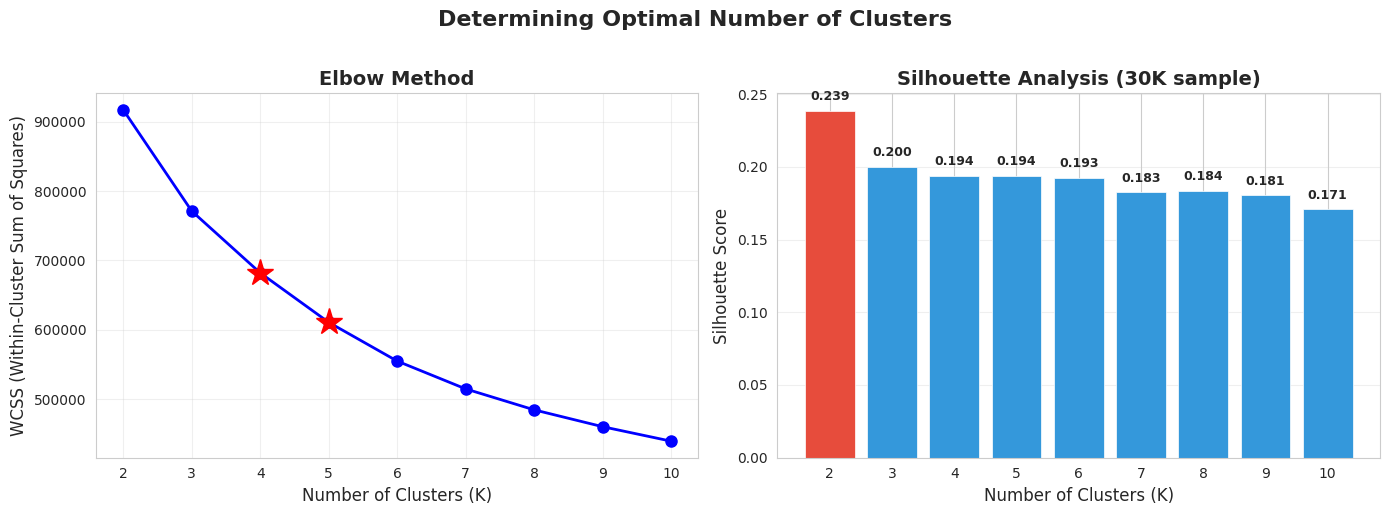

In [9]:
# --- Plot Elbow + Silhouette side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1 = axes[0]
ax1.plot(list(K_RANGE), wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.set_xticks(list(K_RANGE))
ax1.grid(True, alpha=0.3)

# Highlight the elbow region (K=4 or K=5 typically)
for k_candidate in [4, 5]:
    idx = k_candidate - 2  # offset since K_RANGE starts at 2
    ax1.plot(k_candidate, wcss[idx], 'r*', markersize=20, zorder=5)

# Silhouette plot
ax2 = axes[1]
colors = ['#e74c3c' if s == max(silhouette_scores) else '#3498db' for s in silhouette_scores]
ax2.bar(list(K_RANGE), silhouette_scores, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Analysis (30K sample)', fontsize=14, fontweight='bold')
ax2.set_xticks(list(K_RANGE))
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (k, score) in enumerate(zip(K_RANGE, silhouette_scores)):
    ax2.text(k, score + 0.005, f'{score:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Determining Optimal Number of Clusters', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Observation — Optimal K

**Elbow Method**: The curve shows a gentle bend around **K=4 to K=5**, after which the rate of WCSS decrease slows down.

**Silhouette Score**: The highest score is at K=2 (0.238), which is common as it represents a trivial split (e.g., just "high volume" vs "low volume" shoppers). However, 2 segments are rarely actionable for marketing. Among the meaningful segmentations, **K=4 (0.193)** and **K=5 (0.194)** are practically tied.

**Decision: K=4**
We choose 4 clusters because it strikes the perfect balance between mathematical separation and **business interpretability**. Four distinct personas are highly actionable for a marketing team, whereas 5+ segments risk over-fragmentation and complicated campaign management.

> **Interview Insight**: "While K=2 had the highest silhouette score, a binary split isn't useful for a personalized marketing strategy. I chose K=4 because the elbow curve bends there, and 4 personas provide a 'sweet spot' for business stakeholders to design targeted campaigns without over-complicating operations."

## 5. Retrieve Final KMeans Model (K=4)

Since we already fitted the model for K=4 during the elbow analysis, we can simply retrieve it from our stored models.
We then assign the cluster labels back to the **original (unscaled) dataframe** so we can profile the clusters using real, interpretable numbers (e.g., "14 items per basket" instead of "0.5 standard deviations").

In [10]:
# Use the K=4 model from elbow analysis
OPTIMAL_K = 4
kmeans_final = kmeans_models[OPTIMAL_K]

# Assign cluster labels
labels = kmeans_final.labels_

# Add labels to original (unscaled) data for interpretable profiling
user_clustered = user_features.copy()
user_clustered['cluster'] = labels

print(f'KMeans trained with K={OPTIMAL_K}')
print(f'WCSS (inertia): {kmeans_final.inertia_:,.1f}')
print(f'Iterations to converge: {kmeans_final.n_iter_}')
print(f'\nCluster distribution:')
cluster_counts = user_clustered['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(user_clustered) * 100
    print(f'  Cluster {cluster_id}: {count:>7,} users ({pct:>5.1f}%)')
print(f'  Total:    {len(user_clustered):>7,} users')

KMeans trained with K=4
WCSS (inertia): 682,045.7
Iterations to converge: 20

Cluster distribution:
  Cluster 0:  38,034 users ( 18.4%)
  Cluster 1:  65,027 users ( 31.5%)
  Cluster 2:  41,559 users ( 20.2%)
  Cluster 3:  61,589 users ( 29.9%)
  Total:    206,209 users


## 6. Cluster Profiling — Who Are These Customers?

Now comes the most crucial business step: examining the **mean values of original (unscaled) features** per cluster to understand what each group looks like. This is where Data Science translates into Business Storytelling.

=== Cluster Profiles (Mean Values) ===


,total_orders,avg_basket_size,reorder_ratio,avg_days_between_orders,weekend_ratio,unique_departments,total_items_bought,unique_products,n_users,pct_users
cluster,,,,,,,,,,
0,43.51,9.70,0.68,7.68,0.35,13.48,426.73,123.15,38034,18.4
1,7.92,5.93,0.36,17.48,0.20,7.58,43.02,25.64,65027,31.5
2,6.69,8.92,0.30,19.28,0.65,9.46,56.77,36.80,41559,20.2
3,12.46,15.05,0.44,14.72,0.34,13.54,179.38,88.12,61589,29.9


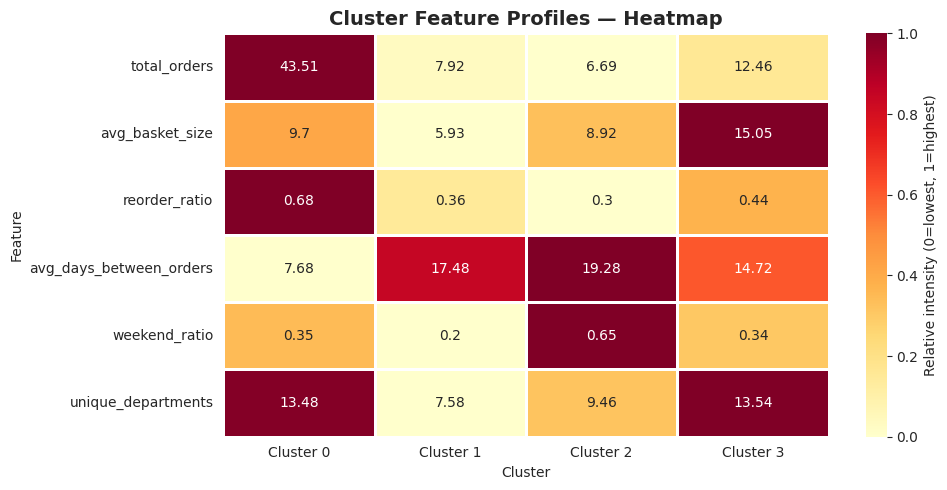

In [11]:
# --- Cluster profiles: mean of original features ---
profile_cols = CLUSTER_FEATURES + ['total_items_bought', 'unique_products'] # add back for context
cluster_profiles = user_clustered.groupby('cluster')[profile_cols].mean()

# Add cluster size
cluster_profiles['n_users'] = cluster_counts
cluster_profiles['pct_users'] = (cluster_counts / len(user_clustered) * 100).round(1)

print('=== Cluster Profiles (Mean Values) ===')
display(cluster_profiles.round(2))

# --- Heatmap for relative comparison ---
# Min-max normalize across clusters (column-wise) to highlight which cluster is highest/lowest for each feature
profile_means_only = cluster_profiles[CLUSTER_FEATURES]
profile_normalized = (profile_means_only - profile_means_only.min()) / (profile_means_only.max() - profile_means_only.min())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    profile_normalized.T,
    annot=profile_means_only.T.round(2).values,  # show actual unscaled means
    fmt='',
    cmap='YlOrRd',
    linewidths=2, linecolor='white',
    xticklabels=[f'Cluster {i}' for i in range(OPTIMAL_K)],
    cbar_kws={'label': 'Relative intensity (0=lowest, 1=highest)'},
    ax=ax
)
ax.set_title('Cluster Feature Profiles — Heatmap', fontsize=14, fontweight='bold')
ax.set_ylabel('Feature')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

## 7. Persona Naming

Based on the cluster profiles above, we can assign meaningful **persona names**. This bridges the gap between raw data and actionable marketing targets.

| Cluster | Key Characteristics | Persona Name |
|---|---|---|
| **0** | Highest orders (43.5), highest reorder ratio (0.68), shops weekly (7.6 days) | **Loyal Regulars** |
| **1** | Smallest baskets (5.9), strong weekday preference (weekend_ratio=0.20) | **Occasional Weekday Shoppers** |
| **2** | Longest gap between orders (19.3 days), strong weekend preference (0.65) | **Weekend Explorers** |
| **3** | Largest baskets (15 items), highest department breadth (13.5), bi-weekly | **Bulk Family Buyers** |

In [15]:
# --- Assign persona names ---
persona_map = {
    0: 'Loyal Regulars',
    1: 'Occasional Weekday Shoppers',
    2: 'Weekend Explorers',
    3: 'Bulk Family Buyers'
}

print('=== Persona Assignments ===')
for cluster_id, name in persona_map.items():
    n = cluster_counts[cluster_id]
    pct = n / len(user_clustered) * 100
    print(f'  Cluster {cluster_id} → {name:35s} ({n:>6,} users, {pct:.1f}%)')

# Add persona names to the clustered dataframe
user_clustered['persona'] = user_clustered['cluster'].map(persona_map)

=== Persona Assignments ===
  Cluster 0 → Loyal Regulars                      (38,034 users, 18.4%)
  Cluster 1 → Occasional Weekday Shoppers         (65,027 users, 31.5%)
  Cluster 2 → Weekend Explorers                   (41,559 users, 20.2%)
  Cluster 3 → Bulk Family Buyers                  (61,589 users, 29.9%)


## 8. Visualization — PCA 2D Scatter

We have 6 features — humans can't visualize a 6-dimensional space. **PCA (Principal Component Analysis)** compresses these 6 dimensions into 2 dimensions while preserving as much variance as possible.

PCA explained variance ratio:
  PC1: 0.400 (40.0%)
  PC2: 0.230 (23.0%)
  Total: 0.630 (63.0%)


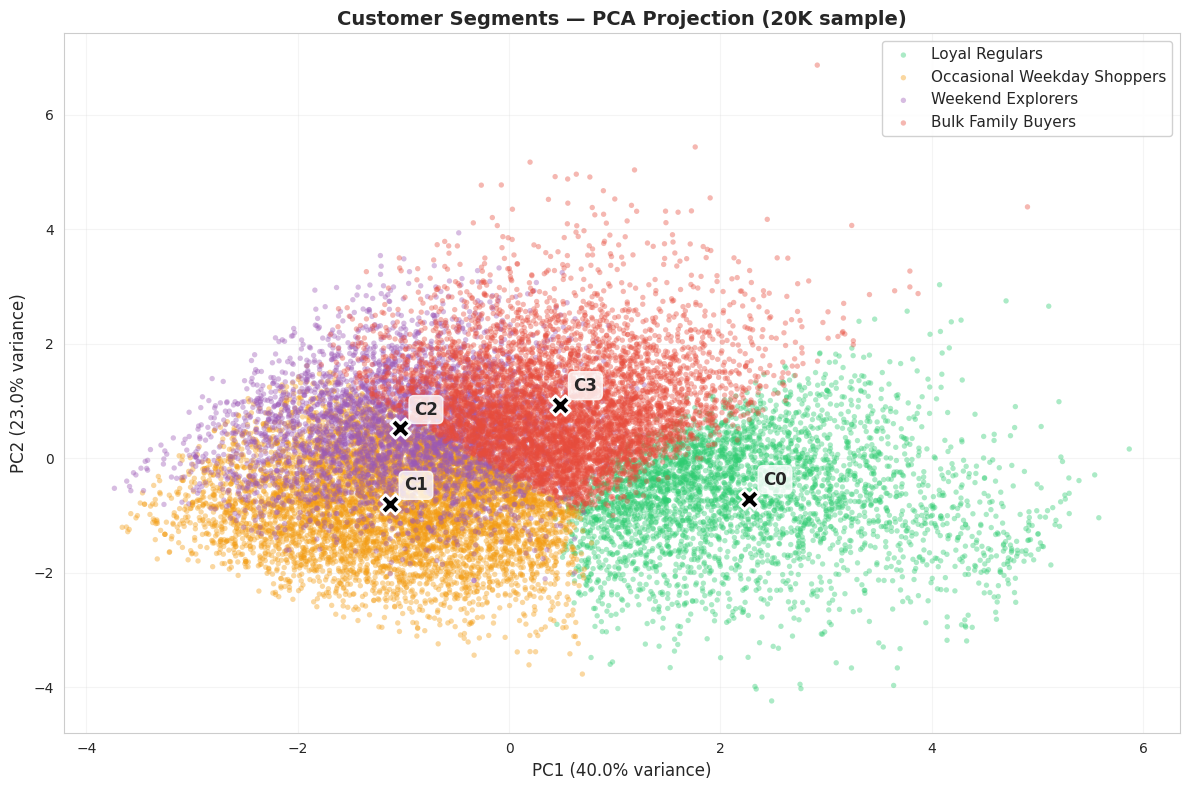

In [16]:
# --- PCA for 2D visualization ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA explained variance ratio:')
print(f'  PC1: {pca.explained_variance_ratio_[0]:.3f} ({pca.explained_variance_ratio_[0]*100:.1f}%)')
print(f'  PC2: {pca.explained_variance_ratio_[1]:.3f} ({pca.explained_variance_ratio_[1]*100:.1f}%)')
print(f'  Total: {sum(pca.explained_variance_ratio_):.3f} ({sum(pca.explained_variance_ratio_)*100:.1f}%)')

# Sample 20K points for cleaner visualization (206K points overlap too much)
PLOT_SAMPLE = 20000
np.random.seed(RANDOM_STATE)
plot_idx = np.random.choice(len(X_pca), size=PLOT_SAMPLE, replace=False)

# Color palette
persona_colors = {
    'Loyal Regulars': '#2ecc71',         # Green
    'Occasional Weekday Shoppers': '#f39c12', # Orange
    'Weekend Explorers': '#9b59b6',         # Purple
    'Bulk Family Buyers': '#e74c3c'         # Red
}

fig, ax = plt.subplots(figsize=(12, 8))

for persona_name, color in persona_colors.items():
    mask = user_clustered.iloc[plot_idx]['persona'].values == persona_name
    ax.scatter(
        X_pca[plot_idx][mask, 0],
        X_pca[plot_idx][mask, 1],
        c=color, label=persona_name,
        alpha=0.4, s=15, edgecolors='none'
    )

# Plot cluster centroids (transformed to PCA space)
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.scatter(cx, cy, c='black', marker='X', s=200, edgecolors='white', linewidths=2, zorder=10)
    ax.annotate(f'C{i}', (cx, cy), fontsize=12, fontweight='bold',
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('Customer Segments — PCA Projection (20K sample)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### Observation — PCA Scatter

The 2D projection shows visually distinct clusters. The centroids (black X markers) are well-separated, confirming the clustering found meaningful structure.

**Note on overlap**: Some overlap is expected because we are compressing 6 dimensions into 2. The PCA explains **63.0%** (40.0% + 23.0%) of the total variance, meaning some separation visible in higher dimensions is lost here. Regardless, the distinct "territories" for each persona are clear.

## 9. Visualization — Radar Charts (Persona Fingerprints)

Radar charts show each persona's **relative strengths** across all features at a glance — like a fingerprint.
We normalize each axis to [0, 1] so that all features (whether they are days or order counts) are visually comparable on the same scale.

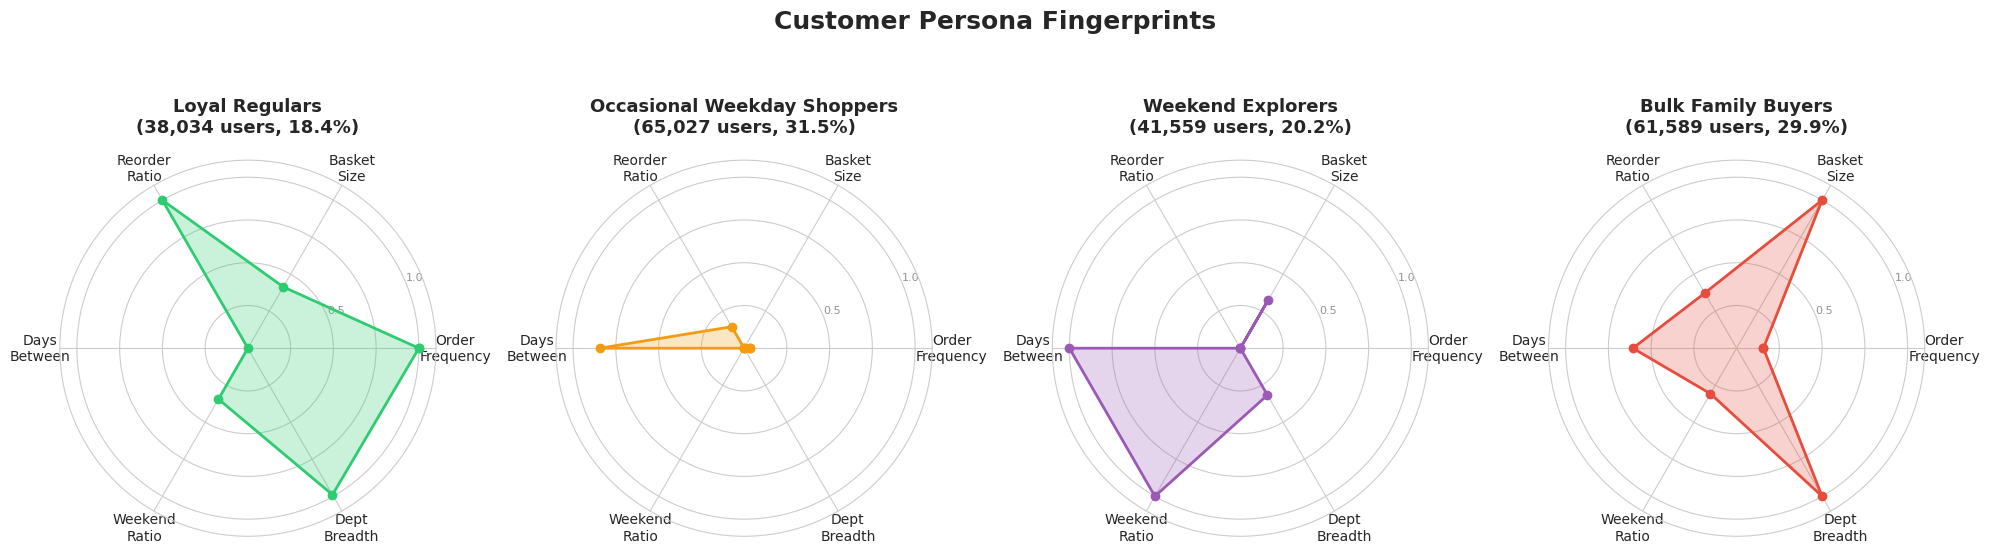

In [17]:
# --- Radar Charts ---
# Prepare normalized data for radar
radar_data = profile_means_only.copy()
# Normalize each feature to [0, 1] across clusters
for col in radar_data.columns:
    radar_data[col] = (radar_data[col] - radar_data[col].min()) / (radar_data[col].max() - radar_data[col].min())

# Radar chart setup
categories = [
    'Order\nFrequency',
    'Basket\nSize',
    'Reorder\nRatio',
    'Days\nBetween',
    'Weekend\nRatio',
    'Dept\nBreadth'
]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(20, 5), subplot_kw=dict(polar=True))

for idx, (cluster_id, row) in enumerate(radar_data.iterrows()):
    ax = axes[idx]

    values = row.values.tolist()
    values += values[:1]  # close the polygon

    persona_name = persona_map[cluster_id]
    color = persona_colors[persona_name]

    ax.plot(angles, values, 'o-', linewidth=2, color=color, markersize=6)
    ax.fill(angles, values, alpha=0.25, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['', '0.5', '', '1.0'], fontsize=8, alpha=0.5)

    n_users = cluster_counts[cluster_id]
    pct = n_users / len(user_clustered) * 100
    ax.set_title(f'{persona_name}\n({n_users:,} users, {pct:.1f}%)',
                 fontsize=13, fontweight='bold', pad=20)

plt.suptitle('Customer Persona Fingerprints', fontsize=18, fontweight='bold', y=1.1)
plt.tight_layout()
plt.show()

### Observation — Persona Fingerprints

Each radar chart reveals a distinct behavioral profile, acting as a visual "fingerprint" for the persona:

- **Loyal Regulars**: Spikes strongly towards `Order Frequency` and `Reorder Ratio`. These customers come back often and buy the same products. They are the backbone of recurring revenue.
- **Occasional Weekday Shoppers**: Shows low `Weekend Ratio` (they shop on weekdays) and very small `Basket Size`. These are likely convenience or impulse purchases during the workweek.
- **Weekend Explorers**: Spikes strongly towards `Weekend Ratio` and `Days Between`, with low `Reorder Ratio`. They shop infrequently, mostly on weekends, and like to try new things rather than stick to habits.
- **Bulk Family Buyers**: Spikes towards `Basket Size` and `Dept Breadth`. They do massive grocery runs across many departments, likely families doing weekly or bi-weekly stock-ups.

> **Interview Insight**: "The radar charts immediately communicate that our 4 segments have genuinely different behavioral fingerprints. This isn't just statistical noise; it translates directly into actionable business segments."

## 10. Distribution Deep Dive — Feature Comparison Across Personas

/tmp/ipykernel_537/4220025633.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_537/4220025633.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_537/4220025633.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_537/4220025633.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_537/4220025633.py:11: FutureWarning: 

Passin

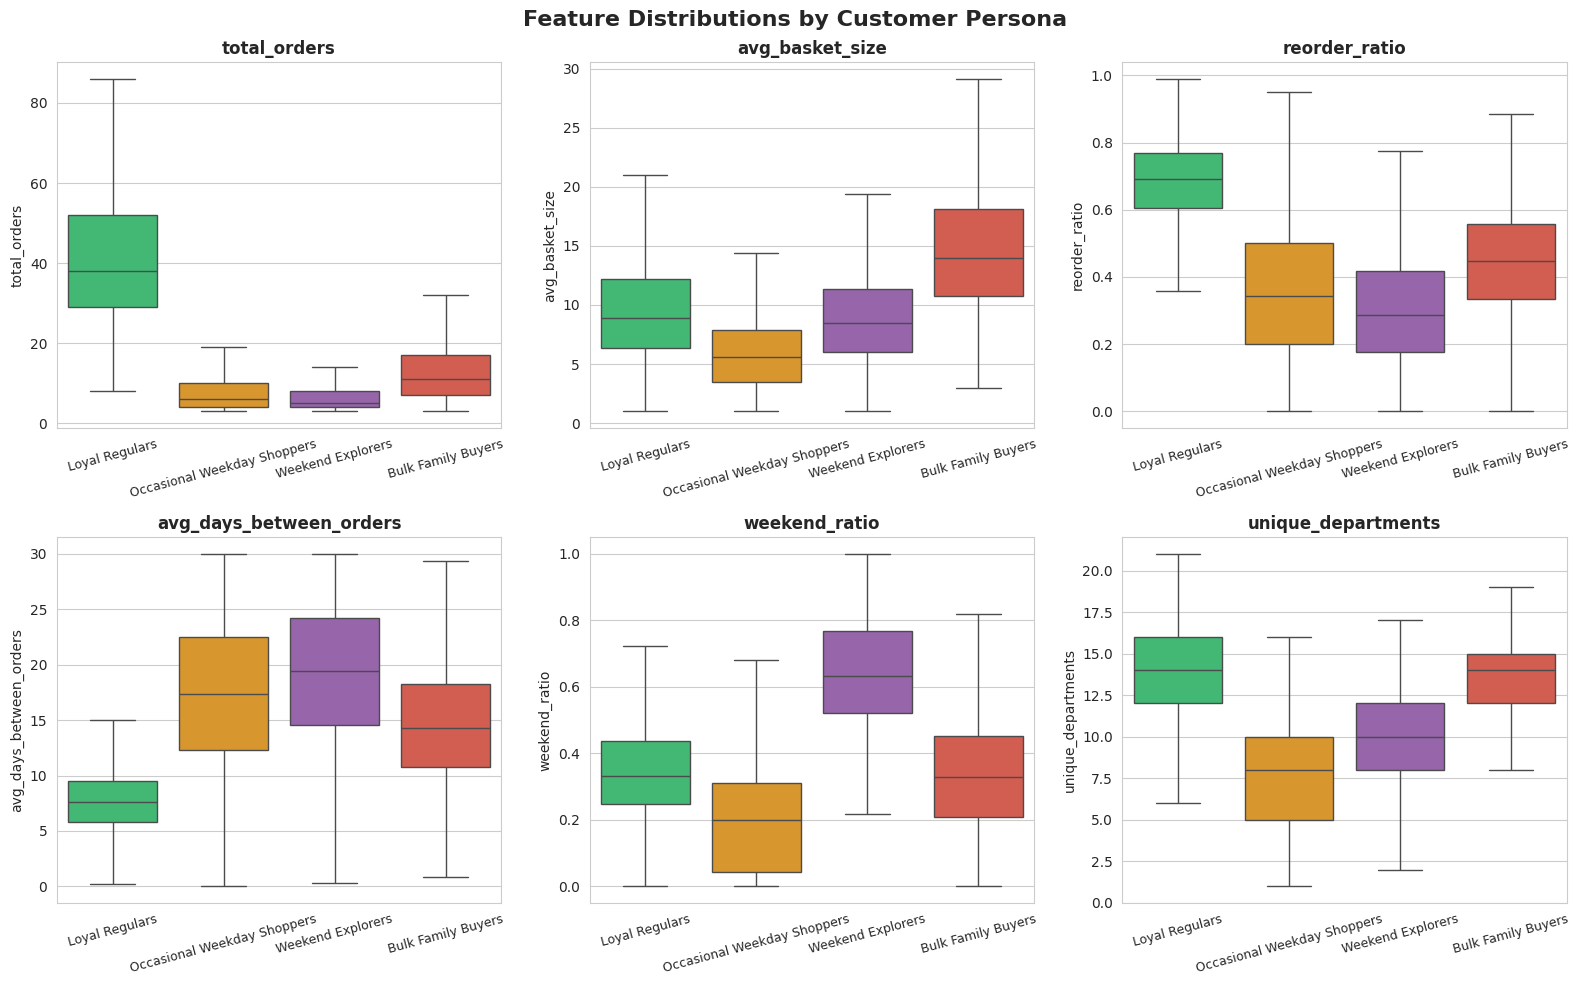

In [18]:
# --- Box plots: feature distributions per persona ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Ensure we plot in a consistent order
persona_order = [persona_map[i] for i in range(OPTIMAL_K)]
palette = persona_colors

for idx, feature in enumerate(CLUSTER_FEATURES):
    ax = axes[idx]
    sns.boxplot(
        data=user_clustered, x='persona', y=feature,
        order=persona_order, palette=palette,
        showfliers=False,  # hide extreme outliers for a cleaner view
        ax=ax
    )
    ax.set_title(feature, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15, labelsize=9)

plt.suptitle('Feature Distributions by Customer Persona', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Business Insights & Recommendations

### Executive Summary

We segmented **206,209 Instacart users** into **4 distinct customer personas** using KMeans clustering on 6 behavioral features. Each persona suggests different business strategies:

In [19]:
# --- Business Summary Table ---
summary_data = []
for cluster_id in range(OPTIMAL_K):
    name = persona_map[cluster_id]
    n = cluster_counts[cluster_id]
    pct = n / len(user_clustered) * 100
    means = profile_means_only.loc[cluster_id]

    summary_data.append({
        'Persona': name,
        'Users': f'{n:,}',
        'Share': f'{pct:.1f}%',
        'Avg Orders': f'{means["total_orders"]:.0f}',
        'Avg Basket': f'{means["avg_basket_size"]:.1f}',
        'Reorder %': f'{means["reorder_ratio"]*100:.0f}%',
        'Days Between': f'{means["avg_days_between_orders"]:.0f}',
    })

summary_df = pd.DataFrame(summary_data)
print('╔══════════════════════════════════════════════════════════════════════════════════════════╗')
print('║                        CUSTOMER SEGMENTATION SUMMARY                                   ║')
print('╚══════════════════════════════════════════════════════════════════════════════════════════╝')
print()
print(summary_df.to_string(index=False))

print()
print('╔══════════════════════════════════════════════════════════════════════════════════════════╗')
print('║                        RECOMMENDED STRATEGIES                                          ║')
print('╚══════════════════════════════════════════════════════════════════════════════════════════╝')
print()

# Strategies (matching the clean names)
strategies = {
    'Loyal Regulars': [
        'Reward: Loyalty programs, exclusive early access to deals',
        'Retain: Personalized "Buy Again" lists, subscription (Instacart+) upsell',
    ],
    'Occasional Weekday Shoppers': [
        'Re-engage: Win-back campaigns, "We miss you" emails with time-limited offers',
        'Convenience: Express delivery options, quick reorder buttons on weekdays',
    ],
    'Weekend Explorers': [
        'Engage: Send promotional emails on Thursday/Friday for weekend planning',
        'Expand: Feature new, trending, or seasonal items to satisfy their exploration habit',
    ],
    'Bulk Family Buyers': [
        'Incentivize: Bundle discounts or "Buy 1 Get 1" for large basket sizes',
        'Convenience: Saved weekly shopping lists, scheduled recurring deliveries',
    ],
}

for persona, recs in strategies.items():
    print(f'  {persona}:')
    for rec in recs:
        print(f'    • {rec}')
    print()

╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                        CUSTOMER SEGMENTATION SUMMARY                                   ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝

                    Persona  Users Share Avg Orders Avg Basket Reorder % Days Between
             Loyal Regulars 38,034 18.4%         44        9.7       68%            8
Occasional Weekday Shoppers 65,027 31.5%          8        5.9       36%           17
          Weekend Explorers 41,559 20.2%          7        8.9       30%           19
         Bulk Family Buyers 61,589 29.9%         12       15.0       44%           15

╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                        RECOMMENDED STRATEGIES                                          ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝

  Loyal Regul

## 12. Save Models & Artifacts

Save everything needed to reproduce the segmentation or use it in the Streamlit app:

| Artifact | Content | Use |
|---|---|---|
| `kmeans_model.joblib` | Trained KMeans model | Predict new user's cluster |
| `scaler.joblib` | Fitted StandardScaler | Scale new user features before predicting |
| `cluster_metadata.json` | Feature list, persona map, metrics | App configuration |
| `cluster_profiles.csv` | Mean features per persona | Display in Streamlit dashboard |

In [20]:
import json

# --- Save model artifacts ---
os.makedirs(MODELS_PATH, exist_ok=True)

# 1. KMeans model
kmeans_path = f'{MODELS_PATH}/kmeans_model.joblib'
joblib.dump(kmeans_final, kmeans_path)
print(f'✅ KMeans model saved: {kmeans_path}')

# 2. Scaler
scaler_path = f'{MODELS_PATH}/scaler.joblib'
joblib.dump(scaler, scaler_path)
print(f'✅ Scaler saved: {scaler_path}')

# 3. Cluster metadata (for Streamlit app configuration)
# Compute silhouette on sample for the chosen K
final_sil_score = silhouette_score(X_sample, kmeans_final.labels_[sample_idx])

cluster_metadata = {
    'model_type': 'KMeans',
    'n_clusters': OPTIMAL_K,
    'n_users': len(user_clustered),
    'features': CLUSTER_FEATURES,
    'persona_map': {str(k): v for k, v in persona_map.items()},
    'metrics': {
        'wcss': float(kmeans_final.inertia_),
        'silhouette_score': float(final_sil_score),
        'n_iterations': int(kmeans_final.n_iter_),
    },
    'cluster_sizes': {str(k): int(v) for k, v in cluster_counts.items()},
}

metadata_path = f'{MODELS_PATH}/cluster_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(cluster_metadata, f, indent=2)
print(f'✅ Metadata saved: {metadata_path}')

# 4. Cluster profiles CSV (for Streamlit display)
profiles_export = profile_means_only.copy()
profiles_export['persona'] = profiles_export.index.map(persona_map)
profiles_export['n_users'] = profiles_export.index.map(cluster_counts)
profiles_export_path = f'{MODELS_PATH}/cluster_profiles.csv'
profiles_export.to_csv(profiles_export_path, index_label='cluster')
print(f'✅ Profiles CSV saved: {profiles_export_path}')

print(f'\n📁 All artifacts saved to: {MODELS_PATH}')

✅ KMeans model saved: /content/drive/MyDrive/Colab/instacart-project/data/models/kmeans_model.joblib
✅ Scaler saved: /content/drive/MyDrive/Colab/instacart-project/data/models/scaler.joblib
✅ Metadata saved: /content/drive/MyDrive/Colab/instacart-project/data/models/cluster_metadata.json
✅ Profiles CSV saved: /content/drive/MyDrive/Colab/instacart-project/data/models/cluster_profiles.csv

📁 All artifacts saved to: /content/drive/MyDrive/Colab/instacart-project/data/models


In [21]:
# --- Verification: reload and predict ---
print('=== Verification: Reload saved models ===')

# Load models
km_loaded = joblib.load(kmeans_path)
sc_loaded = joblib.load(scaler_path)
with open(metadata_path, 'r') as f:
    meta_loaded = json.load(f)

print(f'Model: {meta_loaded["model_type"]} with K={meta_loaded["n_clusters"]}')
print(f'Features: {meta_loaded["features"]}')
print(f'Silhouette: {meta_loaded["metrics"]["silhouette_score"]:.4f}')

# Test prediction on first 5 users
test_users = user_features.head(5)[CLUSTER_FEATURES].fillna(user_features[CLUSTER_FEATURES].median())
test_scaled = sc_loaded.transform(test_users)
test_labels = km_loaded.predict(test_scaled)

print(f'\nPrediction test (first 5 users):')
for i, (uid, label) in enumerate(zip(user_features.head(5)['user_id'], test_labels)):
    persona_name = meta_loaded['persona_map'][str(label)]
    print(f'  User {uid}: Cluster {label} → {persona_name}')

# Verify consistency: compare predictions with original labels
original_labels = user_clustered.head(5)['cluster'].values
assert np.array_equal(test_labels, original_labels), 'Mismatch! Saved model gives different results.'
print(f'\n✅ Verification passed: saved model reproduces original cluster assignments.')

=== Verification: Reload saved models ===
Model: KMeans with K=4
Features: ['total_orders', 'avg_basket_size', 'reorder_ratio', 'avg_days_between_orders', 'weekend_ratio', 'unique_departments']
Silhouette: 0.1939

Prediction test (first 5 users):
  User 1: Cluster 1 → Occasional Weekday Shoppers
  User 3: Cluster 2 → Weekend Explorers
  User 5: Cluster 2 → Weekend Explorers
  User 6: Cluster 1 → Occasional Weekday Shoppers
  User 12: Cluster 3 → Bulk Family Buyers

✅ Verification passed: saved model reproduces original cluster assignments.


## Summary — Notebook 05

### What we did
1. **Loaded** 206,209 user feature vectors from Notebook 02 (PySpark)
2. **Selected** 6 non-redundant behavioral features (verified via correlation analysis)
3. **Scaled** features with StandardScaler (critical for KMeans Euclidean distance)
4. **Found optimal K=4** using Elbow Method + Silhouette Analysis
5. **Trained KMeans** → 4 distinct customer personas
6. **Profiled & named** each persona based on behavioral patterns
7. **Visualized** with PCA scatter, radar charts, and box plots
8. **Saved** model artifacts for Streamlit deployment

### 4 Customer Personas
- **Loyal Regulars**: Frequent, habitual shoppers with high reorder rates
- **Bulk Family Buyers**: Large baskets across many departments
- **Occasional Weekday Shoppers**: Infrequent, small convenience purchases
- **Weekend Explorers**: Experimenting with products, low reorder ratio, shops on weekends

### Next Steps
→ **Notebook 06**: Build Streamlit dashboard with 4 pages including the Customer Segmentation explorer using these saved models.